# Random Variables and Basic Distributions

## Bernoulli and Binomial Distributions

The simplest type of random variable is a variable $X$ that takes on the value $1$ if a certain event occurs and $0$ otherwise. For instance assume that our sample space corresponds to rolling two six-sided dice and the event we are interest in is that the sum of the two dice is 5. 

$$
\begin{aligned}
\Omega &= \{(a, b) \, : \, a, b \in \{1, 2, 3, 4, 5, 6\}\}\\
F &= \{(a, b) \, : \, a+b=5\}\\
X(\omega) &= \begin{cases}
1 & \text{, if }\omega \in F\\
0 & \text{, otherwise}
\end{cases} 
\end{aligned}
$$

$$
X \sim \mathrm{Ber}(p)
$$

$$
p(x) = \begin{cases}
p &, \text{if } x=1\\
1-p &, \text{if } x=0
\end{cases}
$$

If $K = B_1 + \dots + B_n$ with independent Bernoulli random variables $B_i \sim \mathrm{Ber}(p)$ then we say that $K$ is binomially distributed with $n$ trials and success probability $p$ and write
$$
K \sim \mathrm{Bin}(n, p) \enspace .
$$

In [1]:
import numpy as np

rng = np.random.default_rng(seed=0)
y = rng.binomial(20, 0.2, size=20)
y

array([5, 3, 1, 1, 6, 6, 4, 5, 4, 7, 6, 0, 6, 1, 5, 2, 6, 4, 3, 4])

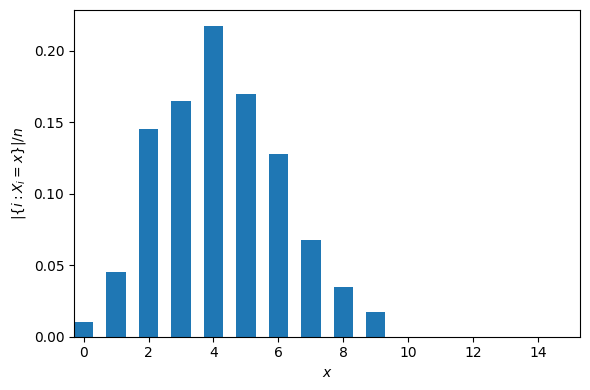

In [2]:
from matplotlib import pyplot as plt
from plotting import histo_int, subplotgrid

y = rng.binomial(20, 0.2, size=400)
fig, ax = subplotgrid('$x$', r'$|\{i: X_i = x\}|/n$', subplotsize=(6, 4))
histo_int(ax[0][0], y, 0, 15)
plt.show()

In this case, the distribution of $K$ is given by the probability mass function
$$
f(k) = {n \choose k} p^k (1-p)^{n-k} 
$$
where
$$
{n \choose k} = \frac{n!}{(n-k)!\,k!}
$$
is the binomial coefficient.

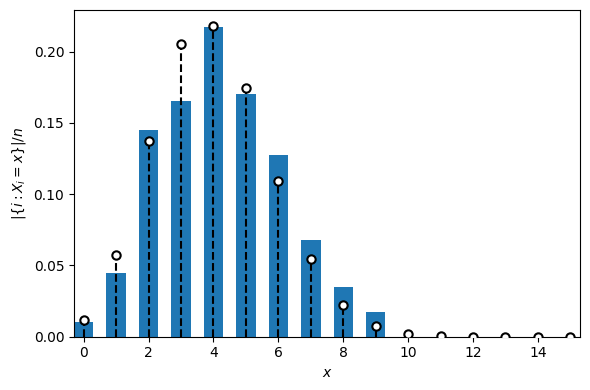

In [3]:
from scipy.special import comb

def binom_pmf(n, p):
    def pmf(x):
        return comb(n, x)*p**x*(1-p)**(n-x)
    return pmf

fig, ax = subplotgrid('$x$', r'$|\{i: X_i = x\}|/n$', subplotsize=(6, 4))
histo_int(ax[0][0], y, 0, 15, pmf=binom_pmf(20, 0.2))
plt.show()

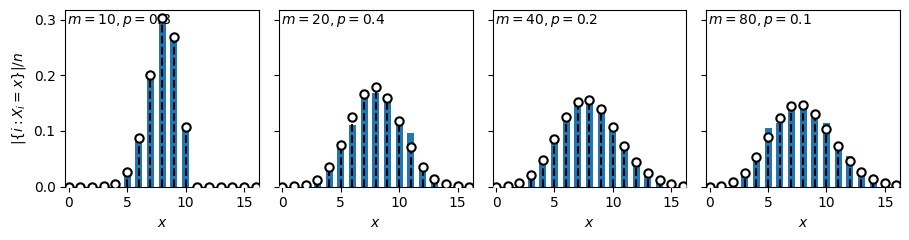

In [31]:
from plotting import apply

ms = np.array([10, 20, 40, 80])
ps = np.array([0.8, 0.4, 0.2, 0.1])
samples = rng.binomial(ms.reshape(1, len(ms), 1), ps.reshape(1, len(ms), 1), size=(1, len(ms), 1000))

intitles = np.array([f'$m={ms[i]}, p={ps[i]}$' for i in range(len(ms))])
fig, ax = subplotgrid('$x$', r'$|\{i: X_i = x\}|/n$', intitles=intitles, subplotsize=(2.3, 2.5))
apply(histo_int, ax, samples, 0, 16, pmf=np.array([[binom_pmf(ms[i], ps[i]) for i in range(len(ms))]]))

## Continuous Uniform Distribution

$$
X \sim \mathrm{Unif}(a, b)
$$

$$
p(x) =
\begin{cases}
0 &, \text{if } x \leq a\\
1/(b-a) &, \text{if } x \in (a, b]\\
0 &, \text{otherwise}
\end{cases}
$$

## Exponential Distribution

### Semantics and Generation

Consider the survival time $T$ of a specific uniform random individual in a decay processes of a very large population (where it makes sense to measure population growth/decay in relative terms instead of in individual discrete units). A standard example for this would be the decay of radioactive material with its atoms as individuals. Specifically, decay with rate $\lambda$ means that after time $T$, a fraction of $\exp(-\lambda T)$ of the population has still survived. 

In this process, we can identify a uniform random individual with a uniform survival quantile $S \sim \mathrm{Unif}(0, 1)$, i.e., the exact fraction of individuals that survived at least until time $T$. Relating the two quantities yields
$$
\begin{aligned}
\exp(-\lambda T) &= S\\
T &= - \lambda^{-1}\ln S
\end{aligned}
$$
and we say that $T$ is an **exponential random variable** with **rate parameter** $\lambda$, denoted as $T \sim \mathrm{Exp}(\lambda)$.

### Connection to Poisson Distribution

An important alternative semantics of an exponential random variable $T \sim \mathrm{Exp}(\lambda)$ is the waiting time until the first event or between two consecutive events in a process where events occur independently and continuously at a fixed average rate (like in a Poisson distribution) $\lambda$. Events can for instance be, people or orders arriving at a queue or the receipt of a phone call or text message. However, such a process is much harder to simulate, hence we implement the simpler one based on the uniform distribution.

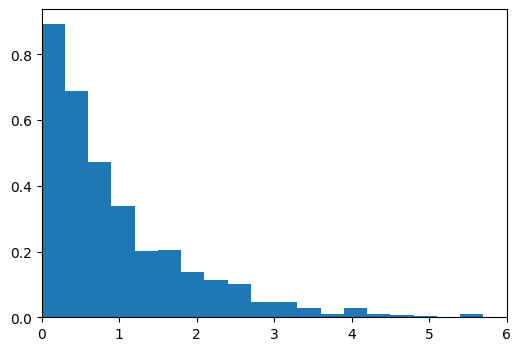

In [5]:
t = rng.uniform(size=1000)
s = - np.log(t)

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_xmargin(0)
plt.hist(s, bins=20, range=(0, 6), density=True)
plt.show()

### Scale Parameterisation and Generation with `numpy`

Realisations of exponential random variables can be generated via the default numpy random generator using the method `exponential`. Importantly, that method, like most others, do not receive a rate but a *scale* parameter $\theta$ that modifies a random variable $T$ of ``standard form'' by multiplying it with $\theta$, i.e., $\theta T$. This scale parameter is the inverse of the rate parameter $\lambda$.

That is a standard exponential $T$ has rate and scale parameter $\lambda=\theta=1$ and $T/\lambda$ has rate $\lambda$.

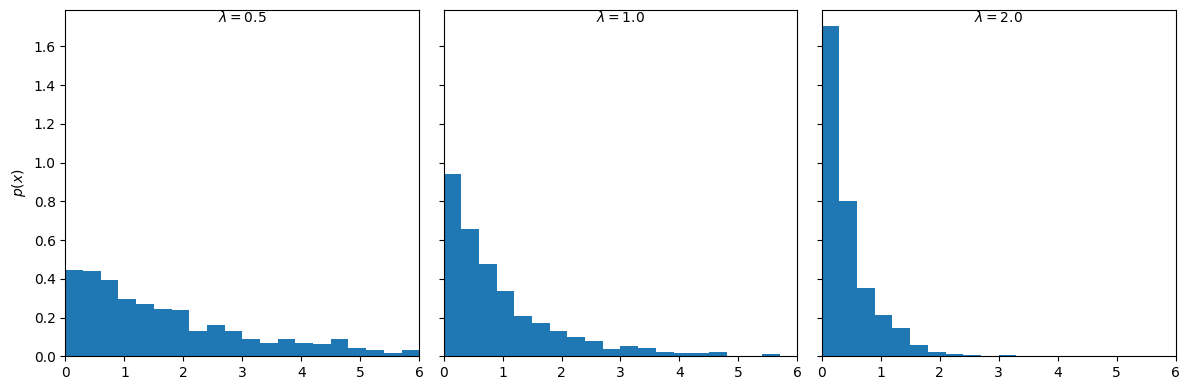

In [6]:
rates = np.array([0.5, 1.0, 2])
samples = rng.exponential(1/rates, size=(1000, 3))

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True, tight_layout=True)
for i in range(len(rates)):
    ax[i].hist(samples[:, i], density=True, range=(0,6), bins=20)
    ax[i].text(0.5, 1, f'$\\lambda={rates[i]}$', transform=ax[i].transAxes, verticalalignment='top', horizontalalignment='center')
ax[0].set_xlim(0, 6)
ax[0].set_ylabel('$p(x)$')
plt.show()

Using the semantics of an exponential variable $T = -\lambda^{-1}\ln S$ as the survival time associated with a uniform random survival fraction $S \sim \mathrm{Unif}(0, 1)$, we can derive the exponential pdf via the standard uniform pdf $p_S(s)=1$ and the variable transformation $t = -\lambda^{-1} \ln(s)$ and its inverse $s=\exp(-\lambda t)$:
$$
\begin{aligned}
p_T(t) &= p_S(\exp(-\lambda t)) \, |\mathrm{d} s / \mathrm{d} t|\\
&= \lambda \exp(-\lambda t)
\end{aligned}
$$

In summary, the probability density function of $T \sim \mathrm{Exp}(\lambda)$ is
$$
p(t \mid \lambda) = \lambda \exp(-\lambda t) \enspace 
$$

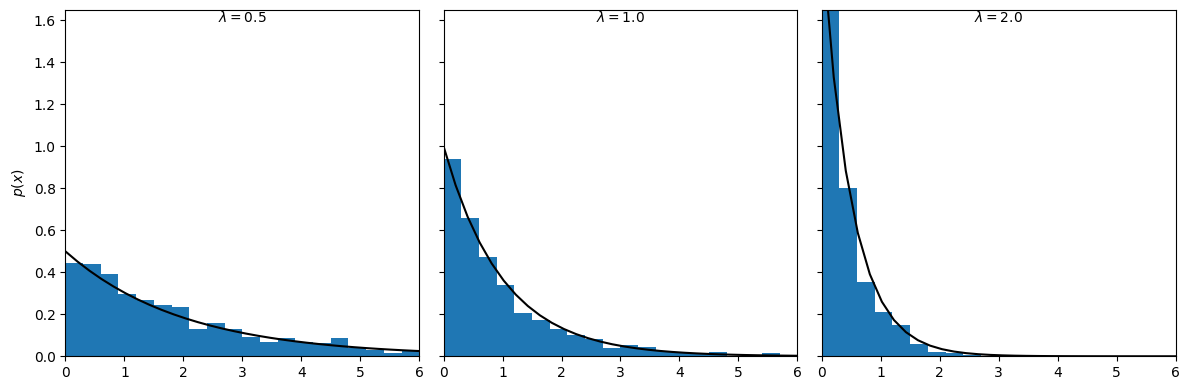

In [7]:
def exponential_pdf(x, rate):
    return rate*np.exp(-rate*x)

x = np.linspace(0, 10)

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True, tight_layout=True)
for i in range(len(rates)):
    ax[i].hist(samples[:, i], density=True, range=(0,6), bins=20)
    ax[i].text(0.5, 1, f'$\\lambda={rates[i]}$', transform=ax[i].transAxes, verticalalignment='top', horizontalalignment='center')
    ax[i].plot(x, exponential_pdf(x, rate=rates[i]), color='k')
ax[0].set_xlim(0, 6)
ax[0].set_ylim(0, 1.65)
ax[0].set_ylabel('$p(x)$')
plt.show()

## Erlang and Gamma Distribution

### Semantics and Generation

A natural extension of the idea of an exponential random variable is to consider the waiting time until $k$ events have occurred, again, in a context where events occur continuously and independently at a fixed rate $\lambda$. In other words, we are defining a new random variable 
$$S_k = X_1 + \dots + X_k$$
as the sum of $k$ independent exponential random variables $X_i \sim \mathrm{Exp}(\lambda)$.

Such a random variable is called an **Erlang random variable** with **shape** parameter $k$ and **rate** parameter $\lambda$ (or alternatively **scale** parameter $1/\lambda$).

(0.0, 30.0)

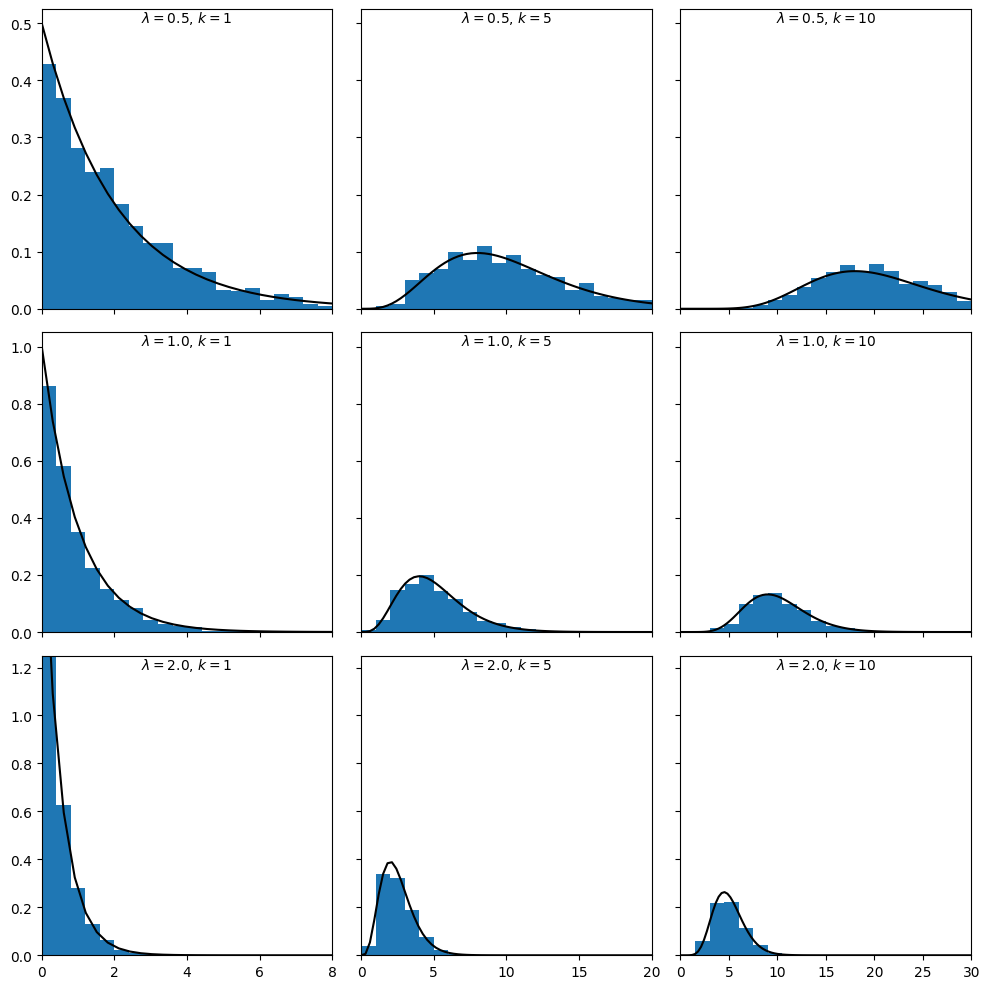

In [8]:
from scipy.stats import gamma

rates = np.array([0.5, 1.0, 2])
shapes = np.array([1, 5, 10])
samples = rng.gamma(shapes.reshape(3, 1), (1/rates).reshape(1, 3), size=(1000, 3, 3))
samples[:, 0, 0]
xlims = [8, 20, 30]
ylims = [0.5, 0.9, 1.25]

x = np.linspace(0, 30, 100)
fig, ax = plt.subplots(3, 3, figsize=(10, 10), sharex='col', sharey='row', tight_layout=True)
for j in range(len(shapes)):
    for i in range(len(rates)):
        ax[i][j].hist(samples[:, j, i], density=True, bins=20, range=(0, xlims[j]))
        ax[i][j].text(0.5, 1, f'$\\lambda={rates[i]}$, $k={shapes[j]}$', transform=ax[i][j].transAxes, verticalalignment='top', horizontalalignment='center')
        ax[i][j].plot(x, gamma.pdf(x, shapes[j], scale=1/rates[i]), color='k')

ax[0][0].set_xlim(0, 8)
ax[2][0].set_ylim(0, 1.25)
ax[0][1].set_xlim(0, 20)
ax[0][2].set_xlim(0, 30)


### Density

To find the pdf of an Erlang distribution, we can proceed by forming convolutions of exponential pdfs. To keep things simple, we first focus on the case of standard exponentials (rate $\lambda=1$). By applying a scale transform, we can later derive the general case.

Let $p_1(x)$ denote the pdf of a standard exponential. For the sum $S_2 = X_1 + X_2$ of two independent exponential random variables $X_1, X_2 \stackrel{\mathrm{iid}}{\sim}\mathrm{Exp}(1)$ the pdf $p_2$ is then given by
$$
\begin{aligned}
p_{2}(s) &= \int_{0}^s p_1(t) \, p_1(s - t) \mathrm d t\\
&= \int_{0}^s \exp(-t) \, \exp(-(s-t)) \mathrm d t\\
&= \exp(-s) \int_{0}^s \,1\, \mathrm d t\\
&=s \exp(-s) \enspace .
\end{aligned}
$$

To establish a pattern, we can go on and find the pdf of $S_3 = S_2 + X_3$ as
$$
\begin{aligned}
p_3(s) &= \int_{0}^s p_2(t) \, p_1(s - t) \mathrm d t\\
&= \int_{0}^s t\exp(-t) \, \exp(-(s-t)) \mathrm d t\\
&= \exp(-s) \int_{0}^s \,t\, \mathrm d t\\
&=\frac{1}{2}s^2 \exp(-s) \enspace .
\end{aligned}
$$

We can recognise that we increase the power of the polynomial term by 1 with every addition. Further, from forming the anti-derivative of the polynomial term, we obtain a factor that is factorial in the number of exponentials added. Generally, assuming that we have already shown that the pdf of $S_k = X_1 + \dots + X_k$ for $X_1, \dots, X_k, X_{k+1} \stackrel{\mathrm{iid}}{\sim}\mathrm{Exp}(1)$ is
$$
p_k(s) = \frac{1}{(k-1)!}s^{k-1} \exp(-s)
$$
then 
$$
\begin{aligned}
p_{k+1}(s) &= \int_{0}^s p_{k}(t) \, p_{1}(s - t) \mathrm d t\\
&= \frac{1}{(k-1)!}\int_{0}^s t^{k-1}\exp(-t) \, \exp(-(s-t)) \mathrm d t\\
&= \frac{1}{(k-1)!} \exp(-s) \int_{0}^s \,t\, \mathrm d t\\
&= \frac{1}{k!} s^k \exp(-s) \enspace .
\end{aligned}
$$

Finally, we can derive the pdf of the general Erlang distribution with rate $\lambda$ by considering the scale transform $T_k = S_k / \lambda$. Then the pdf of $T_k$, denoted $p(t; k, \lambda)$, can be expressed by the pdf of $S_k$, denoted by $p(s; k, 1)$, as

$$
\begin{aligned}
p(t; k, \lambda) &= p(\lambda t; k, 1) \, \mathrm d \lambda t / \mathrm{d t}\\
&= \frac{1}{(k-1)!} (\lambda t)^{k-1} \exp(-\lambda t) \lambda\\
&= \frac{\lambda^k}{(k-1)!} t^{k-1} \exp(-\lambda t) \enspace .
\end{aligned}
$$

## Beta Distribution

Let $X$ and $Y$ two independent Gamma random variables with the same rate parameter, i.e., $X \sim \mathrm{Gamma}(\alpha, \lambda)$ and $Y \sim \mathrm{Gamma}(\beta, \lambda)$. Then the ratio
$$
R = \frac{X}{X+Y}
$$
is called a **Beta** random variable with shape parameters $\alpha>0$ and $\beta>0$, denoted $R \sim \mathrm{Beta}(\alpha, \beta)$, and is described by the probability density function
$$
p(r) = \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)} r^{\alpha-1} (1-r)^{\beta-1} \enspace .
$$

To find the pdf of $R$, we can transform the joint pdf of $X$ and $Y$ to the joint pdf of $T=X + Y$ and $R=X/(X+Y)$ and then use the law of total probability to find the marginal pdf of $R$.
Technically, the first step is described by
$$
\begin{aligned}
p_{T, R}(t, r) = p_{X, Y}(x(t, r), y(t, r)) \left| J_{t, r}(x,y) \right |
\end{aligned}
$$
with the change of variables $t(x,y) = x + y$, $r(x,y) = x / (x + y)$, inverse transformations
$$
\begin{aligned}
x(t, r)&=rt\\
y(t, r)&=(1-r)t
\end{aligned}
$$
and the Jacobian matrix
$$
J_{t, r}(x,y) = \begin{bmatrix} \partial x/\partial t & \partial x/\partial r \\ \partial t/\partial x & \partial t/\partial y\end{bmatrix} = \begin{bmatrix} r & t \\ 1-r & -t\end{bmatrix} \enspace .
$$
Plugging in the Jacobian determinant 
$$
\left| J_{t, r}(x,y) \right | = |-rt - (1-r)t| = |rt - (r+1)t| = t 
$$
into the above expression, we arrive at the joint pdf
$$
\begin{aligned}
p_{T,R}(t, r) &= \frac{1}{\Gamma(\alpha)} x^{\alpha-1} \exp(-x) \frac{1}{\Gamma(\beta)} y^{\beta - 1} \exp(-y) \,t\\
&=\frac{1}{\Gamma(\alpha)\Gamma(\beta)} x^{\alpha-1} y^{\beta - 1} \exp(-(x+y)) \,t\\
&=\frac{1}{\Gamma(\alpha)\Gamma(\beta)} (rt)^{\alpha-1} ((1-r)t)^{\beta - 1} \exp(-t) \,t\\
&=\frac{1}{\Gamma(\alpha)\Gamma(\beta)} t^{\alpha+\beta-1} \exp(-t) \, r^{\alpha-1}(1-r)^{\beta - 1} \enspace .
\end{aligned}
$$
From there, we can find the marginal via the law of total probability
$$
\begin{aligned}
p_{R}(r) &= \int_0^\infty p_{T, R}(t, r) \mathrm{d} t \\
&= \frac{1}{\Gamma(\alpha)\Gamma(\beta)}  \underbrace{\int_0^\infty t^{\alpha+\beta-1} \exp(-t) \mathrm{d}t}_{\Gamma(\alpha+\beta)} \,r^{\alpha-1}(1-r)^{\beta - 1} \\
&= \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)} r^{\alpha-1}(1-r)^{\beta - 1} \enspace .
\end{aligned}
$$

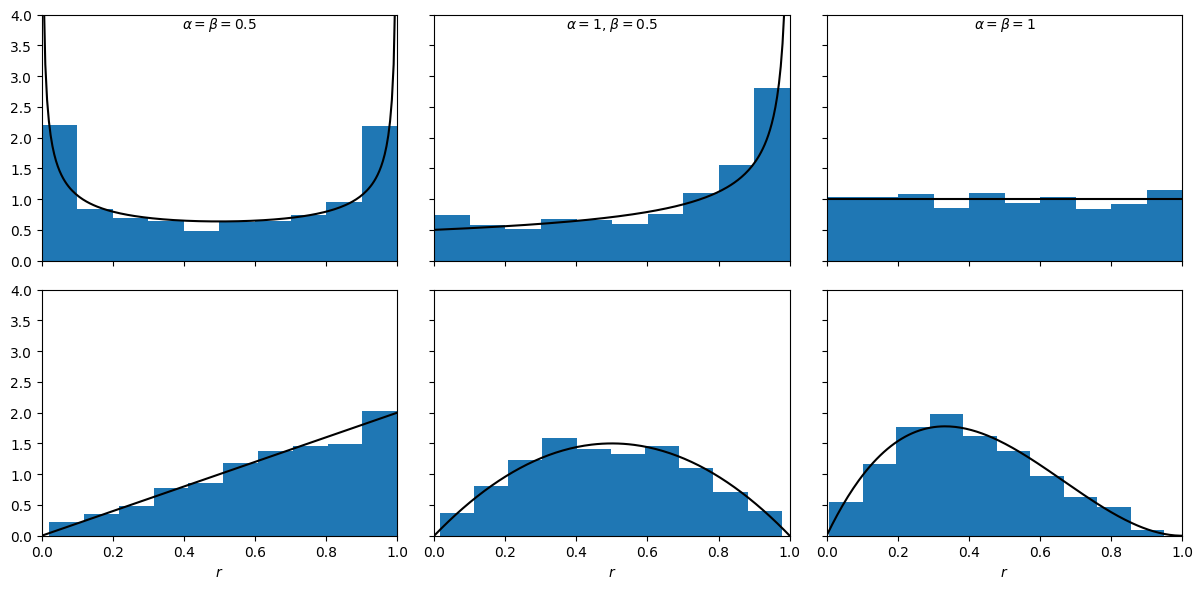

In [9]:
from scipy.special import beta as beta_fct
from scipy.stats import beta

def beta_pdf(x, alpha, beta):
    return x**(alpha-1)*(1-x)**(beta-1)/beta_fct(alpha, beta)

x = np.linspace(0, 1, 200, endpoint=True)

n = 500
r_05_05 = rng.beta(0.5, 0.5, size=n)
r_1_05 = rng.beta(1, 0.5, size=n)
r_1_1 = rng.beta(1, 1, size=n)
r_2_1 = rng.beta(2, 1, size=n)
r_2_2 = rng.beta(2, 2, size=n)
r_2_3 = rng.beta(2, 3, size=n)

fig, ax = plt.subplots(2, 3, figsize=(12, 6), sharey=True, sharex=True, tight_layout=True)

ax[0][0].hist(r_05_05, density=True)
ax[0][0].set_xmargin(0)
# ax[0].plot(x, beta_pdf(x, 0.5, 0.5))
ax[0][0].plot(x, beta.pdf(x, 0.5, 0.5), color='k')
ax[0][0].text(0.5, 1, r'$\alpha=\beta=0.5$', transform=ax[0][0].transAxes, horizontalalignment='center', verticalalignment='top')

ax[0][1].hist(r_1_05, density=True)
ax[0][1].plot(x, beta.pdf(x, 1, 0.5), color='k')
ax[0][1].set_xmargin(0)
ax[0][1].text(0.5, 1, r'$\alpha=1$, $\beta=0.5$', transform=ax[0][1].transAxes, horizontalalignment='center', verticalalignment='top')

ax[0][2].hist(r_1_1, density=True)
ax[0][2].plot(x, beta.pdf(x, 1, 1), color='k')
ax[0][2].set_xmargin(0)
ax[0][2].text(0.5, 1, r'$\alpha=\beta=1$', transform=ax[0][2].transAxes, horizontalalignment='center', verticalalignment='top')

ax[1][0].hist(r_2_1, density=True)
ax[1][0].plot(x, beta.pdf(x, 2, 1), color='k')
ax[1][0].set_xmargin(0)

ax[1][1].hist(r_2_2, density=True)
ax[1][1].plot(x, beta.pdf(x, 2, 2), color='k')
ax[1][1].set_xmargin(0)

ax[1][2].hist(r_2_3, density=True)
ax[1][2].plot(x, beta.pdf(x, 2, 3), color='k')
ax[1][2].set_xmargin(0)

ax[0][0].set_ylim(0, 4)
ax[1][0].set_xlabel('$r$')
ax[1][1].set_xlabel('$r$')
ax[1][2].set_xlabel('$r$')


plt.show()

## Beta Prime

Let $Y$ be a Beta random variable with shape parameters, i.e., $Y \sim \mathrm{Beta}(\alpha, \beta)$ and let 
$$
X = \frac{Y}{1-Y}
$$
be the corresponding **odds transform**. Then we say that $X$ is a **Beta prime** random variable with shape parameters $\alpha$ and $\beta$, denoted $X \sim \mathrm{Beta}'(\alpha, \beta)$.

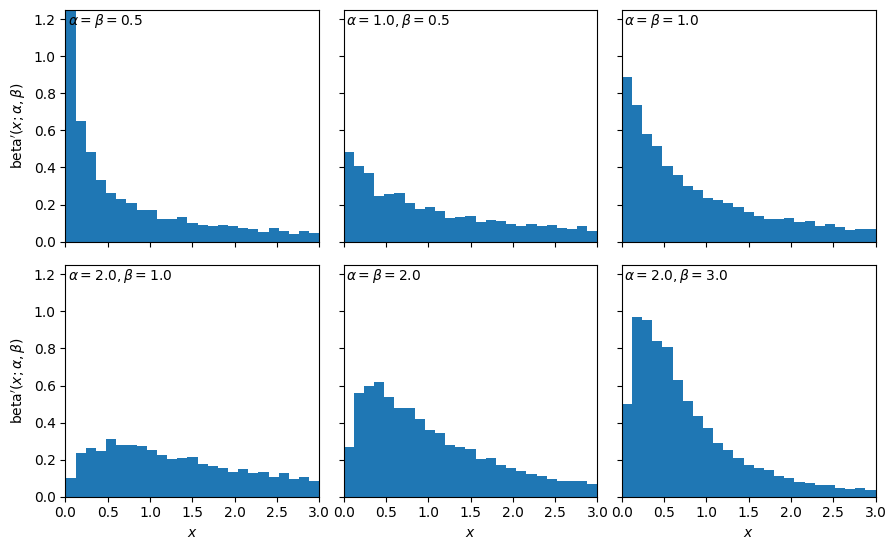

In [17]:
from plotting import subplotgrid, apply, plot, histo

alphas = np.array([[0.5, 1, 1], 
                   [2, 2, 2]])
betas = np.array([[0.5, 0.5, 1],
                  [1, 2, 3]])

rvs = rng.beta(alphas[:,:,np.newaxis], betas[:,:,np.newaxis], size=(2, 3, 10000))
rvs = rvs/(1-rvs)

intitles = [[f'$\\alpha={alphas[i][j]}, \\beta={betas[i][j]}$' if alphas[i][j]!=betas[i][j] else f'$\\alpha=\\beta={betas[i][j]}$'
             for j in range(3)]
             for i in range(2)]

xs = np.linspace(0.001, 3, 200, endpoint=True)
fig, ax = subplotgrid('$x$', r"$\mathrm{beta}'(x; \alpha, \beta)$", intitles=intitles, ylims=(0, 1.25), xlims=(0, 3), subplotsize=(3, 2.8))
apply(histo, ax, rvs, bins=25, range=(0, 3))
plt.show()

### Density

To derive the probability density function of $X \sim \mathrm{Beta}'(\alpha, \beta)$, we can start as usual with the generative definition $X = Y / (1 - Y)$ with $Y \sim \mathrm{Beta}(\alpha, \beta)$ and derive the inverse transform 
$$
\begin{aligned}
\frac{y}{1-y} &= x &\Leftrightarrow\\
0 &= x - xy - y &\Leftrightarrow \\
0 &= x - y(x+1) &\Leftrightarrow\\
y &= \frac{x}{1 + x}
\end{aligned}
$$
and its derivative
$$
\frac{\mathrm{d}y}{\mathrm{d}x} = \frac{1 + x - x}{(1+x)^2} = (1+x)^{-2} \enspace .
$$

Then we find the probability density function of $X$ via the change of variable formula as
$$
\begin{aligned}
\mathrm{beta}'(x; \alpha, \beta) &= \mathrm{beta}(y(x); \alpha, \beta) \left | \frac{\mathrm{d}y}{\mathrm{d}x}\right |\\
&=\frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)} \left(\frac{x}{1+x}\right)^{\alpha-1}\left(1 - \frac{x}{1+x}\right)^{\beta - 1} \frac{1}{(1+x)^2}\\
&=\frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)} \left(\frac{x}{1+x}\right)^{\alpha-1}\left(\frac{1}{1+x}\right)^{\beta - 1} \frac{1}{(1+x)^2}\\
&=\frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)} x^{\alpha-1} (1+x)^{-\alpha - \beta} \enspace .
\end{aligned}
$$

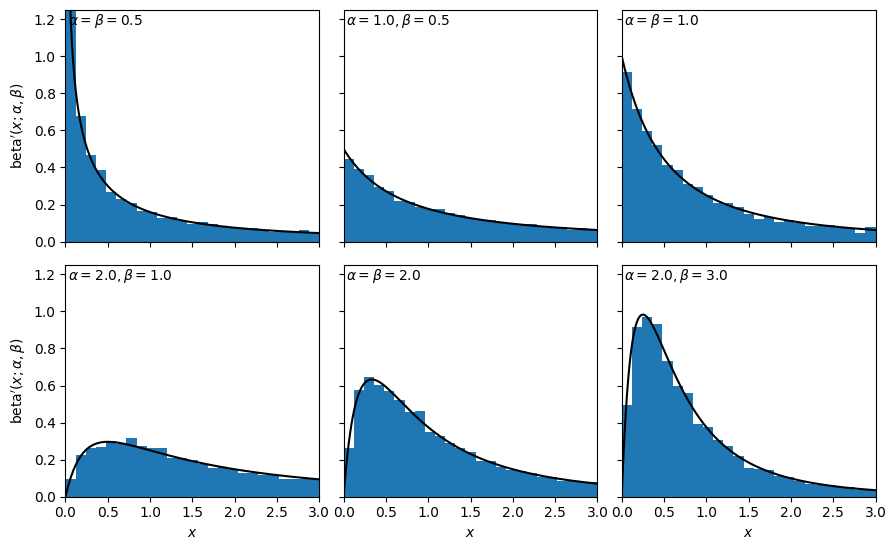

In [16]:
def beta_prime_pdf(x, alpha, beta):
    return x**(alpha-1)*(1+x)**(-beta-alpha)/beta_fct(alpha, beta)

xs = np.linspace(0.001, 3, 200, endpoint=True)
fig, ax = subplotgrid('$x$', r"$\mathrm{beta}'(x; \alpha, \beta)$", intitles=intitles, ylims=(0, 1.25), xlims=(0, 3), subplotsize=(3, 2.8))
apply(plot, ax, xs, beta_prime_pdf(xs, alphas[:,:,np.newaxis], betas[:,:,np.newaxis]), c='k')
apply(histo, ax, rvs, bins=25, range=(0, 3))
plt.show()